# MPC Multi-Horizon Comparison (Aligned Events)


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

from drl_weight_plot_utils import (
    build_model_specs,
    load_raindata,
    load_record,
    pick_events_by_peak_gradient,
    plot_delta_regression_figure,
    set_plot_style,
    validate_required_records,
    get_flooding_cso_series,
    get_inflow_series,
)

set_plot_style()


In [2]:
# Core configuration
START_IDX = 50
NUM_RAINFALLS = 30
ONE_STEP_MINUTES = 5
DESIGN_N_PICK = 4
REAL_RAIN_IDS = [0, 1, 2, 3]

BASELINE_RECORD_PATH = 'results/HC.npy'
BASELINE_PATH = ['env4']
GI_ONLY_RECORD_PATH = 'results/HC_GI.npy'
GI_ONLY_PATH = ['env3']

REAL_BASELINE_RECORD_PATH = 'results_m_real/HC.npy'
REAL_BASELINE_PATH = ['env4']
REAL_GI_ONLY_RECORD_PATH = 'results_m_real/HC_GI.npy'
REAL_GI_ONLY_PATH = ['env3']

MPC_MODELS = [
    {
        'label': 'MPC h=1',
        'path': 'results/MPC_GI.npy',
        'real_path': 'results_m_real/MPC_GI.npy',
        'color': '#1f77b4',
        'linestyle': '-',
        'marker': 'o',
    },
    {
        'label': 'MPC h=3',
        'path': 'results_mpc_horizons/MPC_GI_h3_all_rainfalls.npy',
        'real_path': 'results_m_real_mpc_horizons/MPC_GI_real_h3.npy',
        'color': '#ff7f0e',
        'linestyle': '--',
        'marker': 's',
    },
    {
        'label': 'MPC h=5',
        'path': 'results_mpc_horizons/MPC_GI_h5_all_rainfalls.npy',
        'real_path': 'results_m_real_mpc_horizons/MPC_GI_real_h5.npy',
        'color': '#2ca02c',
        'linestyle': '-.',
        'marker': '^',
    },
]

CONTROL_FIGURE_PATH = 'figures_mpc_horizon_compare_aligned/control_performance_mpc_horizons_aligned.png'
DELTA_REG_FIGURE_PATH = 'figures_mpc_horizon_compare_aligned/gli_delta_regression_mpc_horizons_aligned.png'
GLI_PROCESS_FIGURE_PATH = 'figures_mpc_horizon_compare_aligned/gli_process_mpc_horizons_aligned.png'

MPC_MODELS


[{'label': 'MPC h=1',
  'path': 'results/MPC_GI.npy',
  'real_path': 'results_m_real/MPC_GI.npy',
  'color': '#1f77b4',
  'linestyle': '-',
  'marker': 'o'},
 {'label': 'MPC h=3',
  'path': 'results_mpc_horizons/MPC_GI_h3_all_rainfalls.npy',
  'real_path': 'results_m_real_mpc_horizons/MPC_GI_real_h3.npy',
  'color': '#ff7f0e',
  'linestyle': '--',
  'marker': 's'},
 {'label': 'MPC h=5',
  'path': 'results_mpc_horizons/MPC_GI_h5_all_rainfalls.npy',
  'real_path': 'results_m_real_mpc_horizons/MPC_GI_real_h5.npy',
  'color': '#2ca02c',
  'linestyle': '-.',
  'marker': '^'}]

In [3]:
required_paths = {
    'baseline': BASELINE_RECORD_PATH,
    'gi_only': GI_ONLY_RECORD_PATH,
    'real_baseline': REAL_BASELINE_RECORD_PATH,
    'real_gi_only': REAL_GI_ONLY_RECORD_PATH,
}
for spec in MPC_MODELS:
    required_paths[f"model::{spec['label']}"] = spec['path']
    required_paths[f"real_model::{spec['label']}"] = spec['real_path']

resolved_paths = validate_required_records(required_paths)
raindata = load_raindata()
rain_ids = list(range(START_IDX, START_IDX + NUM_RAINFALLS))

baseline_record = load_record(BASELINE_RECORD_PATH)
gi_only_record = load_record(GI_ONLY_RECORD_PATH)
real_baseline_record = load_record(REAL_BASELINE_RECORD_PATH)
real_gi_only_record = load_record(REAL_GI_ONLY_RECORD_PATH)

model_specs = build_model_specs(MPC_MODELS)
real_model_specs = build_model_specs([
    {
        'label': spec['label'],
        'path': spec['real_path'],
        'color': spec['color'],
        'linestyle': spec['linestyle'],
        'marker': spec['marker'],
    }
    for spec in MPC_MODELS
])

chosen_design_events, chosen_design_peaks = pick_events_by_peak_gradient(
    raindata,
    START_IDX,
    NUM_RAINFALLS,
    DESIGN_N_PICK,
)
chosen_events = chosen_design_events + REAL_RAIN_IDS

peak_values = []
for rainfall_index in range(START_IDX, START_IDX + NUM_RAINFALLS):
    rain_event = raindata[rainfall_index]
    intensities = [float(value[1]) for value in rain_event]
    peak_values.append(max(intensities) if intensities else 0.0)
peak_values = np.asarray(peak_values, dtype=float)

print('Loaded models:', [spec['label'] for spec in model_specs])
print('Resolved baseline path:', resolved_paths['baseline'])
print('Resolved GI-only path:', resolved_paths['gi_only'])
print('Resolved real baseline path:', resolved_paths['real_baseline'])
print('Resolved real GI-only path:', resolved_paths['real_gi_only'])
print('Selected design events:', chosen_design_events)
print('Selected design peaks:', chosen_design_peaks)
print('Selected mixed events:', chosen_events)


Loaded models: ['MPC h=1', 'MPC h=3', 'MPC h=5']
Resolved baseline path: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results\HC.npy
Resolved GI-only path: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results\HC_GI.npy
Resolved real baseline path: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results_m_real\HC.npy
Resolved real GI-only path: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results_m_real\HC_GI.npy
Selected design events: [70, 64, 67, 51]
Selected design peaks: [81.38139521835302, 136.99042512240572, 161.3605100623962, 228.33281936149768]
Selected mixed events: [70, 64, 67, 51, 0, 1, 2, 3]


## Control Performance Figure


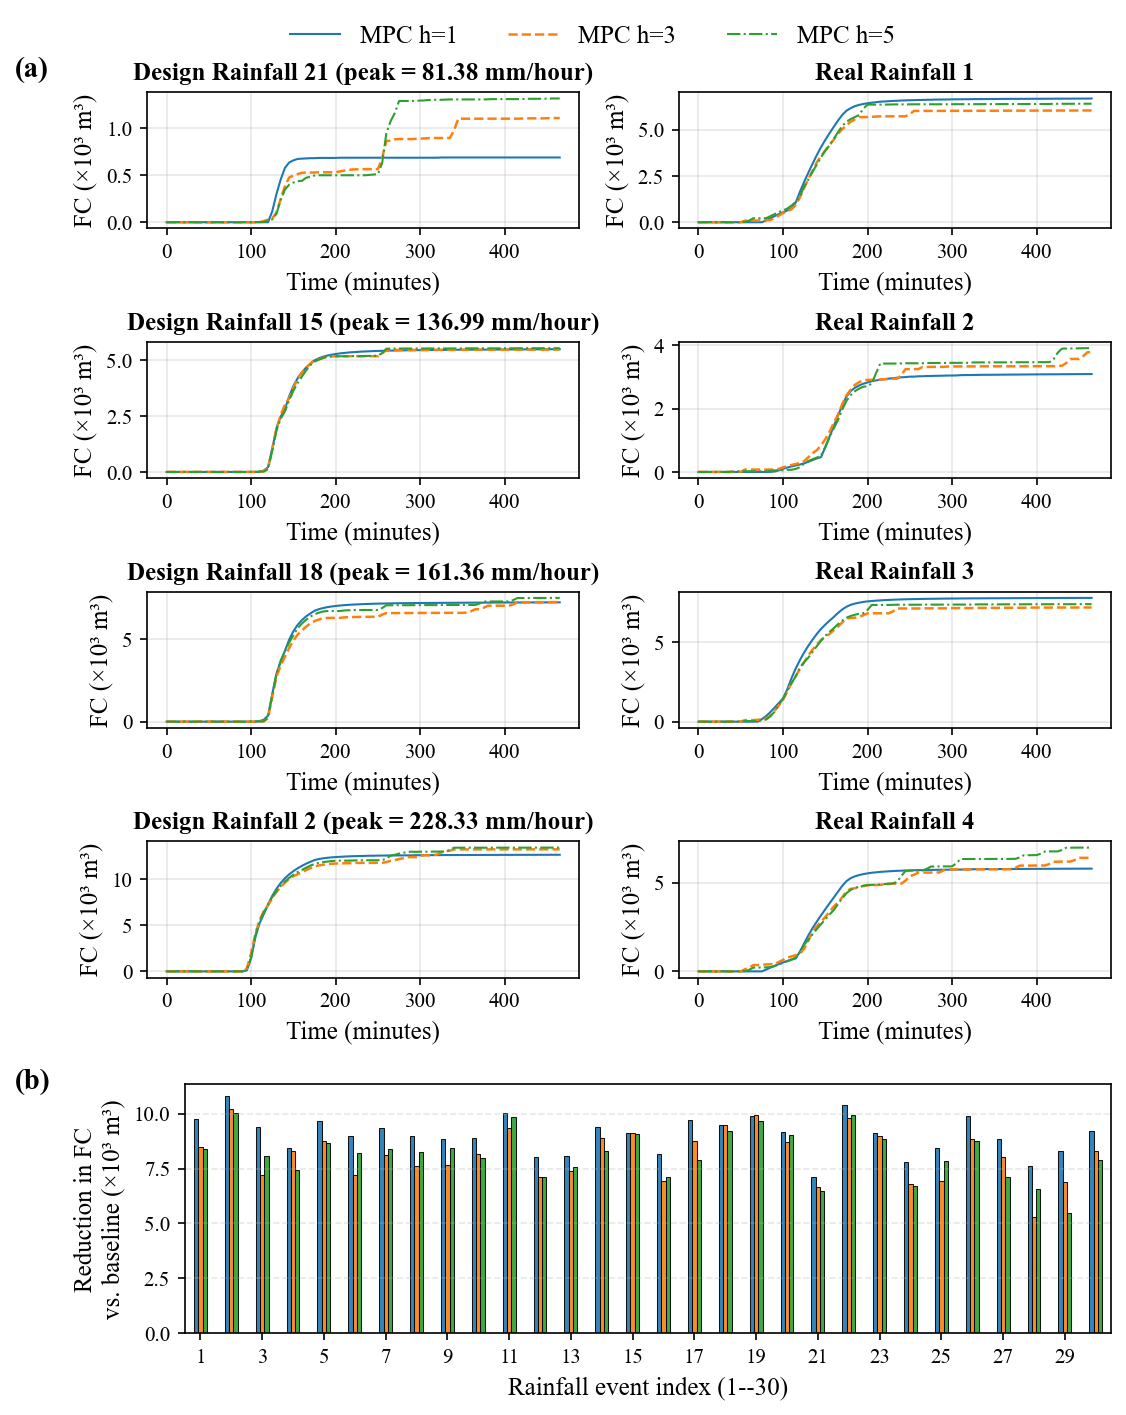

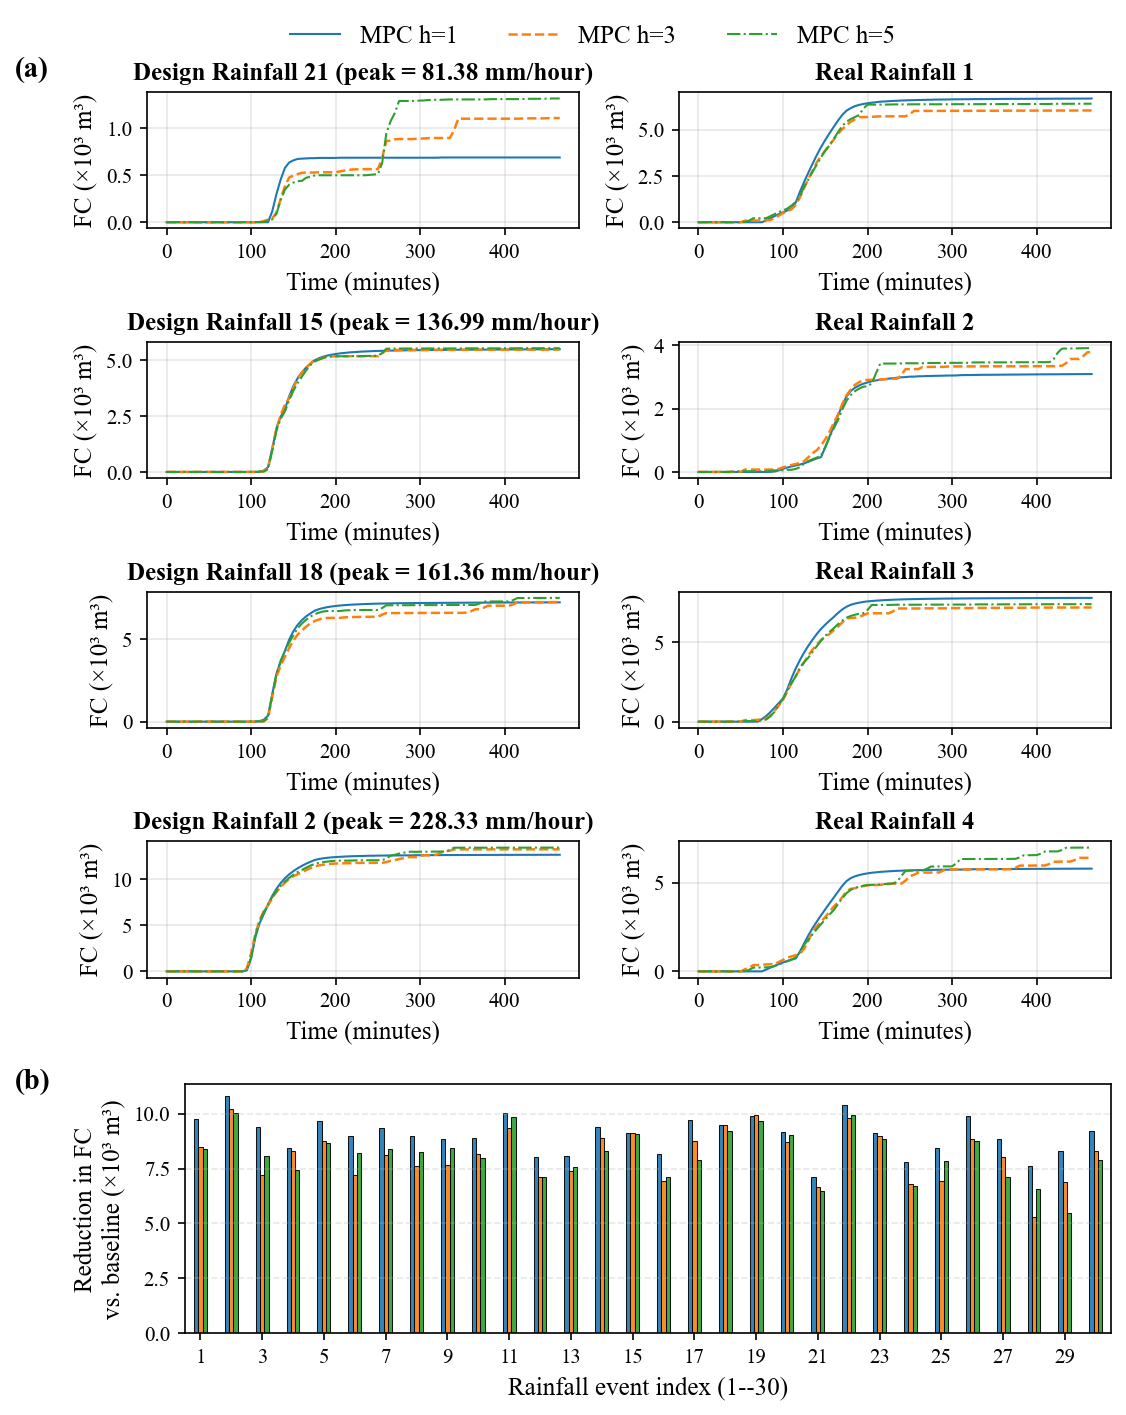

In [4]:
def compute_improvements_vs_baseline(base_record, base_path, model_specs, rain_ids):
    improvement_map = {spec['label']: [] for spec in model_specs}
    for rain_id in rain_ids:
        rainfall_key = f'rainfall{rain_id}'
        base_last = get_flooding_cso_series(base_record, rainfall_key, base_path)[-1]
        for spec in model_specs:
            model_last = get_flooding_cso_series(spec['record'], rainfall_key, spec['data_path'])[-1]
            improvement_map[spec['label']].append(base_last - model_last)
    return {label: np.asarray(values, dtype=float) for label, values in improvement_map.items()}

improvements = compute_improvements_vs_baseline(
    base_record=baseline_record,
    base_path=BASELINE_PATH,
    model_specs=model_specs,
    rain_ids=rain_ids,
)

n_pick = len(chosen_events)
n_col = 2
n_row = math.ceil(n_pick / n_col)

fig = plt.figure(figsize=(7, 9), dpi=150, constrained_layout=True)
outer = GridSpec(nrows=2, ncols=1, figure=fig, height_ratios=[4, 1], hspace=0.1)
gs_top = outer[0].subgridspec(nrows=n_row, ncols=n_col, wspace=0.05, hspace=0.05)
axes_top = np.empty((n_row, n_col), dtype=object)
for r in range(n_row):
    for c in range(n_col):
        axes_top[r, c] = fig.add_subplot(gs_top[r, c])
ax_bar = fig.add_subplot(outer[1, 0])

line_handles = []
line_labels = []

for i, ev in enumerate(chosen_events[:n_pick]):
    rainfall_key = f'rainfall{ev}'
    col = i // n_row
    row = i % n_row
    ax = axes_top[row, col]

    current_specs = model_specs if i < DESIGN_N_PICK else real_model_specs

    for spec in current_specs:
        series = get_flooding_cso_series(spec['record'], rainfall_key, spec['data_path'])
        minutes = np.arange(len(series)) * ONE_STEP_MINUTES
        handle, = ax.plot(
            minutes,
            series,
            label=spec['label'],
            color=spec['color'],
            linestyle=spec['linestyle'],
            linewidth=1.2 if spec['linestyle'] == '--' else 1.0,
        )
        line_handles.append(handle)
        line_labels.append(handle.get_label())

    local_idx = ev - START_IDX
    if i < DESIGN_N_PICK:
        ax.set_title(f'Design Rainfall {str(int(ev) - 49)} (peak = {peak_values[local_idx]:.2f} mm/hour)', fontweight='bold')
    else:
        ax.set_title(f'Real Rainfall {str(int(ev) + 1)}', fontweight='bold')
    ax.set_ylabel('FC (×10³ m³)')
    ax.set_xlabel('Time (minutes)')
    ax.grid(True, alpha=0.3)

for i in range(n_pick, n_row * n_col):
    fig.delaxes(axes_top[i // n_col, i % n_col])

unique = {}
for h, lab in zip(line_handles, line_labels):
    if lab not in unique:
        unique[lab] = h
handles_unique = list(unique.values())
labels_unique = list(unique.keys())

color_map = {spec['label']: spec['color'] for spec in model_specs}
gap_factor = 1.8
x_base = np.arange(NUM_RAINFALLS) * gap_factor
bar_width = 0.25
bar_offsets = {'MPC h=1': -bar_width, 'MPC h=3': 0.0, 'MPC h=5': bar_width}

for label in ['MPC h=1', 'MPC h=3', 'MPC h=5']:
    ax_bar.bar(
        x_base + bar_offsets[label],
        improvements[label],
        width=bar_width,
        color=color_map[label],
        edgecolor='black',
        linewidth=0.5,
        alpha=0.9,
        label=label,
    )

ax_bar.set_xlabel('Rainfall event index ({}--{})'.format(1, 30))
ax_bar.set_ylabel('Reduction in FC\nvs. baseline (×10³ m³)')
tick_step = 2 if NUM_RAINFALLS <= 60 else 5
ax_bar.set_xticks(x_base[::tick_step])
ax_bar.set_xticklabels([str(i) for i in range(1, 31, tick_step)], rotation=0)
ax_bar.margins(x=0.01)
ax_bar.grid(axis='y', linestyle='--', alpha=0.3)

fig.legend(handles_unique, labels_unique, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.text(-0.05, 1.00, '(a)', ha='left', va='top', fontsize=14, fontweight='bold')
fig.text(-0.05, 0.25, '(b)', ha='left', va='top', fontsize=14, fontweight='bold')

from pathlib import Path
save_path = Path(CONTROL_FIGURE_PATH)
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=300, bbox_inches='tight')

fig_control = fig
fig_control


## GLI / GCI Delta Regression Figure

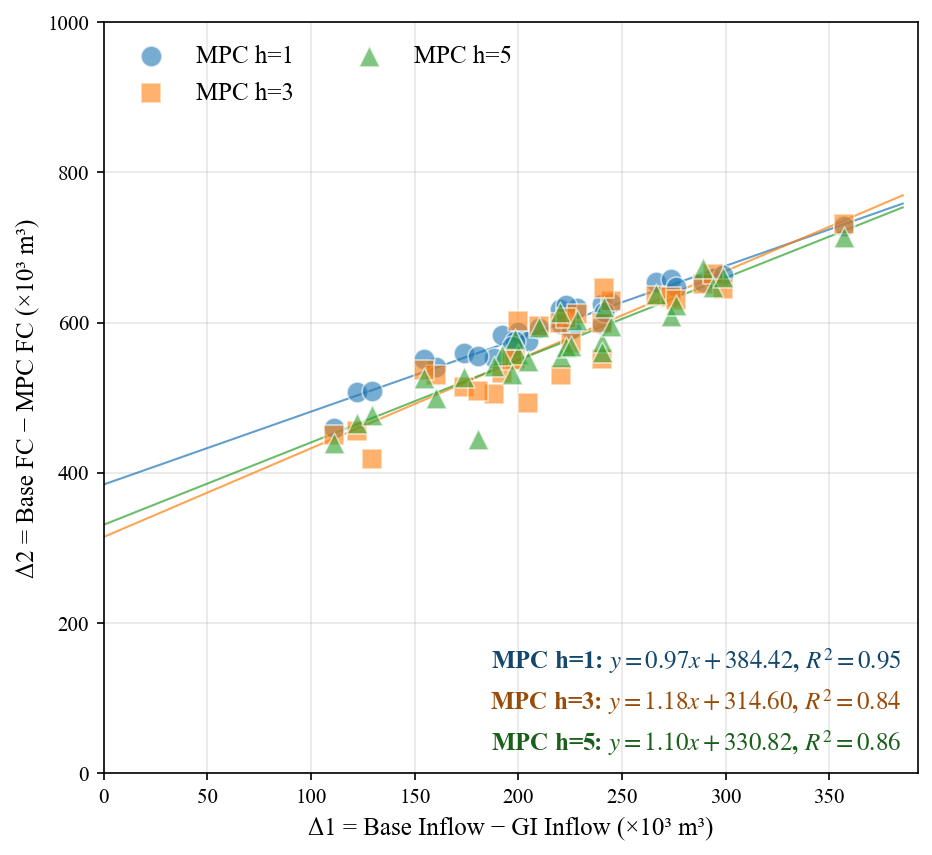

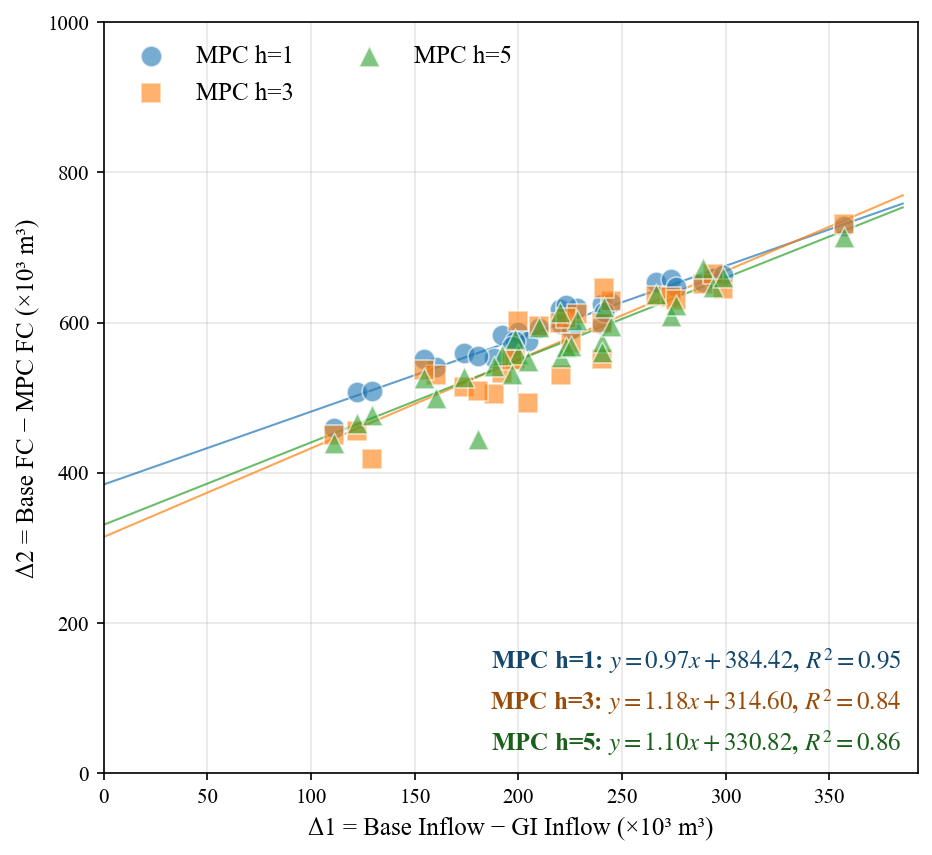

In [5]:
fig_reg, delta_1, delta_2_map = plot_delta_regression_figure(
    model_specs=model_specs,
    base_record=baseline_record,
    base_path=BASELINE_PATH,
    gi_record=gi_only_record,
    gi_path=GI_ONLY_PATH,
    rain_ids=rain_ids,
    compare_name='MPC',
    save_path=DELTA_REG_FIGURE_PATH,
)
fig_reg